# **FINAL PROJECT BASED INTERNSHIP VINIX7**

## **SISTEM REKOMENDASI PENEMPATAN INDUSTRI** 
## **Berdasarkan Preferensi Gaya Kerja dan Work Values Mahasiswa**

Kelompok 2



**TAHAP 1: DATA PREPROCESSING**

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek
import warnings
warnings.filterwarnings('ignore')

Meload Dataset dari Tes Kesiapan Vinix7 ke dalam Jupyter

In [2]:
# 1. LOAD DATASET
# ==========================================
df = pd.read_excel('data_karir_2.xlsx', engine='openpyxl')

Melakukan Standarisasi String.

In [3]:
# 2. STANDARDIZASI STRING
# ==========================================
df['Program Studi'] = df['Program Studi'].astype(str).str.lower().str.strip()
df['Tempat Magang'] = df['Tempat Magang'].astype(str).str.lower().str.strip()
df['Dream Job'] = df['Dream Job'].astype(str).str.lower().str.strip()

Melakukan MAPPING, mengklasifikkasikan untuk mengurangi Noise pada Model.

In [4]:
# 3. MAPPING (UNTUK MENGURANGI NOISE)
# ==========================================
def map_jurusan(x):
    if x in ['nan', 'none', '-']: return 'Lainnya'
    if any(k in x for k in ['teknik', 'informatika', 'sistem', 'komputer', 'data', 'statistika', 'matematika', 'sains', 'fisika', 'it']): return 'STEM_Tech'
    if any(k in x for k in ['psikologi', 'sastra', 'hukum', 'sosiologi', 'hubungan']): return 'Soshum'
    if any(k in x for k in ['manajemen', 'komunikasi', 'ilmu komunikasi', 'bisnis', 'ekonomi', 'akuntansi']): return 'Bisnis_Komunikasi'
    if any(k in x for k in ['desain', 'dkv', 'seni', 'visual']): return 'Seni_Kreatif'
    return 'Lainnya'

def map_dream_job(x):
    if x in ['nan', 'none', '-', '']: return 'Belum Menentukan'
    if any(k in x for k in ['data', 'software', 'ai', 'machine', 'programmer', 'developer', 'it', 'tech', 'engineer', 'cyber', 'web']): 
        return 'Tech Data Engineering'
    if any(k in x for k in ['finance', 'bank', 'akuntan', 'auditor', 'keuangan', 'invest', 'pajak']): 
        return 'Finance Banking'
    if any(k in x for k in ['bisnis', 'manajemen', 'consultant', 'hr', 'manager', 'admin', 'analis', 'analyst']): 
        return 'Business Management'
    if any(k in x for k in ['marketing', 'kreatif', 'desain', 'content', 'seo', 'copywriter', 'ui', 'ux', 'sosmed', 'media']): 
        return 'Creative Marketing'
    return 'Industri Lainnya'

# 4. EKSEKUSI MAPPING & BINARISASI
# ==========================================
df['Program Studi'] = df['Program Studi'].apply(map_jurusan)
df['Dream Job'] = df['Dream Job'].apply(map_dream_job)
df['Tempat Magang'] = df['Tempat Magang'].apply(lambda x: 0 if x in ['nan', 'none', '-', 'belum', 'tidak ada'] else 1)

Menghapuskan Fitur-Fitur yang tidak dibutuhkan oleh model.

In [5]:
# 5. PEMANGKASAN FITUR (FEATURE SELECTION)
# ==========================================
# Menghapus Fitur-Fitur Noise yang tidak termasuk dalam variabel fitur berpengaruh
TARGET = 'Rekomendasi Industri 1'
kolom_noise = ['Rekomendasi Industri 2', 'Verdict Kesiapan', 'Total Score', 'Archetype', 
               'Perguruan Tinggi', 'Kode Referensi', 'Bidang Minat', 'Work Values']

X = df.drop(columns=[TARGET] + kolom_noise, errors='ignore')
y = df[TARGET]

Melakukan ENCODING

In [6]:
# 6. ENCODING
# ==========================================
X_encoded = pd.get_dummies(X, drop_first=True)

print("=== STATUS ARSITEKTUR ===")
print(f"Dimensi Fitur Akhir : {X_encoded.shape}")
print(f"Distribusi Tempat Magang:\n{df['Tempat Magang'].value_counts()}\n")

# ==========================================
# 7. EVALUASI (SMOTETomek + 5-Fold CV)
# ==========================================
smote_tomek = SMOTETomek(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

pipeline = Pipeline(steps=[('resampling', smote_tomek), ('model', rf_model)])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Menjalankan Evaluasi 5-Fold CV")
cv_results = cross_validate(pipeline, X_encoded, y, cv=skf, scoring=('f1_macro', 'accuracy'), n_jobs=-1)

print("\n=== HASIL AKHIR: RANDOM FOREST + SMOTE TOMEK ===")
print(f"Rata-rata Akurasi  : {cv_results['test_accuracy'].mean() * 100:.2f}%")
print(f"Rata-rata Macro F1 : {cv_results['test_f1_macro'].mean():.4f}")

=== STATUS ARSITEKTUR ===
Dimensi Fitur Akhir : (1392, 50)
Distribusi Tempat Magang:
Tempat Magang
0    976
1    416
Name: count, dtype: int64

Menjalankan Evaluasi 5-Fold CV

=== HASIL AKHIR: RANDOM FOREST + SMOTE TOMEK ===
Rata-rata Akurasi  : 41.45%
Rata-rata Macro F1 : 0.2049


**TAHAP2: BENCHMARKING DAN ANALISIS KOMPARASI MODEL**

In [7]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

# 1. Syarat Mutlak XGBoost: Target harus berupa angka (0, 1, 2...), bukan string
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. Definisikan Petarung
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "LightGBM": LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss')
}

# 3. Melihat komparasi 5-Fold dengan SMOTETomek
print("=== KOMPARASI ALGORITMA MODEL (SMOTETOMEK + 5-FOLD CV) ===")

for name, model in models.items():
    print(f"Sedang melatih dan mengevaluasi {name}...")
    # Pipeline dirakit ulang untuk setiap model agar adil
    pipeline = Pipeline(steps=[('resampling', smote_tomek), ('model', model)])
    
    # Eksekusi evaluasi
    cv_results = cross_validate(pipeline, X_encoded, y_encoded, cv=skf, scoring=('f1_macro', 'accuracy'), n_jobs=-1)
    
    # Kalkulasi skor
    acc = cv_results['test_accuracy'].mean() * 100
    f1 = cv_results['test_f1_macro'].mean()
    print(f"-> {name} | Akurasi: {acc:.2f}% | Macro F1: {f1:.4f}\n")

=== KOMPARASI ALGORITMA MODEL (SMOTETOMEK + 5-FOLD CV) ===
Sedang melatih dan mengevaluasi Random Forest...
-> Random Forest | Akurasi: 41.45% | Macro F1: 0.2049

Sedang melatih dan mengevaluasi LightGBM...
-> LightGBM | Akurasi: 41.38% | Macro F1: 0.1921

Sedang melatih dan mengevaluasi XGBoost...
-> XGBoost | Akurasi: 40.37% | Macro F1: 0.1932



**TAHAP3: MAPPING GROUP DAN OPTIMASI MODEL TERBAIK**

In [8]:
# 1. MELAKUKAN GROUPING TERHADAP TARGET INDUSTRI
def klaster_target(industri):
    ind = str(industri).lower()
    if any(k in ind for k in ['tech', 'software', 'ecommerce', 'edtech']):
        return 'Bidang Tech dan Digital' # Gaya agile, aktif dan cepat
    elif any(k in ind for k in ['perbankan', 'pemerintahan', 'manufaktur', 'healthcare']):
        return 'Industri Konvensional Terstruktur' # Gaya stabil, formal, dan terstruktur
    elif any(k in ind for k in ['agency', 'ngo', 'consulting']):
        return 'Industri Kreatif dan Proyek' # Gaya Kolaboratif, fleksibel dan berbasis proyek
    else:
        return 'Industri Konvensional Terstruktur' # Default/Lainnya dilempar ke kelas paling netral

# 2. EKSEKUSI TARGET BARU
y_macro = y.apply(klaster_target)

# Validasi Distribusi Target Baru
print("=== DISTRIBUSI TARGET MAKRO BARU ===")
print(y_macro.value_counts())

# 3. ENCODING TARGET BARU
le_macro = LabelEncoder()
y_macro_encoded = le_macro.fit_transform(y_macro)

# 4. ARENA EVALUASI FINAL (LightGBM + SMOTETomek pada Target Makro)
print("\nMenjalankan Evaluasi 5-Fold dengan Target Makro (LightGBM)...")

lgbm_model = LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)
pipeline_final = Pipeline(steps=[
    ('resampling', SMOTETomek(random_state=42)), 
    ('model', lgbm_model)
])

cv_results_final = cross_validate(pipeline_final, X_encoded, y_macro_encoded, cv=skf, scoring=('f1_macro', 'accuracy'), n_jobs=-1)

print("\n=== HASIL KONSOLIDASI TARGET FINAL ===")
print(f"Rata-rata Akurasi  : {cv_results_final['test_accuracy'].mean() * 100:.2f}%")
print(f"Rata-rata Macro F1 : {cv_results_final['test_f1_macro'].mean():.4f}")


=== DISTRIBUSI TARGET MAKRO BARU ===
Rekomendasi Industri 1
Bidang Tech dan Digital              592
Industri Konvensional Terstruktur    431
Industri Kreatif dan Proyek          369
Name: count, dtype: int64

Menjalankan Evaluasi 5-Fold dengan Target Makro (LightGBM)...

=== HASIL KONSOLIDASI TARGET FINAL ===
Rata-rata Akurasi  : 50.86%
Rata-rata Macro F1 : 0.4863


**Melihat Perbedaan antara LightGBM dengan dan tanpa SMOTETomek**

In [9]:
# MEMBANDINGKAN DAMPAK MODEL: LIGHTGBM MURNI VS SMOTETOMEK
# ==========================================
print("=== KOMPARASI MODEL TANPA DAN DENGAN SMOTETOMEK ===")

# 1. Pipeline Lama (Pakai SMOTETomek)
pipeline_smote = Pipeline(steps=[
    ('resampling', SMOTETomek(random_state=42)), 
    ('model', LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1))
])

# 2. Pipeline Baru (Hanya LightGBM + Class Weight)
pipeline_murni = Pipeline(steps=[
    ('model', LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1))
])

# Eksekusi Evaluasi Model Pake SMOTE
cv_smote = cross_validate(pipeline_smote, X_encoded, y_macro_encoded, cv=skf, scoring=('f1_macro', 'accuracy'), n_jobs=-1)

# Eksekusi Evaluasi Model Murni (Tanpa SMOTE)
cv_murni = cross_validate(pipeline_murni, X_encoded, y_macro_encoded, cv=skf, scoring=('f1_macro', 'accuracy'), n_jobs=-1)

# Komparasi Hasil
print("\n[ DENGAN SMOTETOMEK ]")
print(f"Akurasi : {cv_smote['test_accuracy'].mean() * 100:.2f}% | Macro F1: {cv_smote['test_f1_macro'].mean():.4f}")

print("\n[ TANPA SMOTETOMEK (MURNI LIGHTGBM) ]")
print(f"Akurasi : {cv_murni['test_accuracy'].mean() * 100:.2f}% | Macro F1: {cv_murni['test_f1_macro'].mean():.4f}")

=== KOMPARASI MODEL TANPA DAN DENGAN SMOTETOMEK ===

[ DENGAN SMOTETOMEK ]
Akurasi : 50.86% | Macro F1: 0.4863

[ TANPA SMOTETOMEK (MURNI LIGHTGBM) ]
Akurasi : 51.29% | Macro F1: 0.4927


Berdasarkan hasil komparasi, maka SMOTETomek dianggap tidak memiliki pengaruh signifikan dan hanya membebani model, maka penghapusan SMOTETomek akan dilakukan untuk meringankan beban model.

Melakukan Transisi dari Default Parameter ke **Bayesian Optimization (Optuna)**

In [10]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

print("=== MEMULAI OPTIMASI BAYESIAN DENGAN OPTUNA ===")

def objective(trial):
    # 1. Ruang Pencarian yang Rasional untuk Data Kecil
    param = {
        'objective': 'multiclass',
        'metric': 'multi_logloss',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'class_weight': 'balanced', # Wajib dipertahankan untuk mengawal imbalanced data
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 60),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0)
    }

    # 2. Inisiasi model dengan Parameter Iterasi Saat Ini
    lgbm_tuning = LGBMClassifier(**param)

    # 3. Evaluasi Menggunakan Model Utama: 5-Fold Stratified CV
    # X_encoded dan y_macro_encoded harus sudah tersedia di environment
    scores = cross_val_score(lgbm_tuning, X_encoded, y_macro_encoded, 
                             cv=skf, scoring='f1_macro', n_jobs=-1)
    
    return scores.mean()

# 4. Mencari nilai F1-Macro Tertinggi
optuna.logging.set_verbosity(optuna.logging.WARNING) # Matikan log berisik
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) # Lakukan 50 percobaan cerdas

# 5. Cetak Hasil Analisis
print("\n=== HASIL OPTIMASI TAHAP 1 ===")
print(f"F1-Macro Tertinggi (Tuning) : {study.best_value:.4f}")
print("Parameter Paling Mematikan :")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

=== MEMULAI OPTIMASI BAYESIAN DENGAN OPTUNA ===

=== HASIL OPTIMASI TAHAP 1 ===
F1-Macro Tertinggi (Tuning) : 0.5368
Parameter Paling Mematikan :
  - learning_rate: 0.03099899673129621
  - num_leaves: 24
  - max_depth: 9
  - min_child_samples: 32
  - feature_fraction: 0.5184349672587325
  - subsample: 0.794445472290298


**TAHAP4: ANALISIS FITUR PENTING**

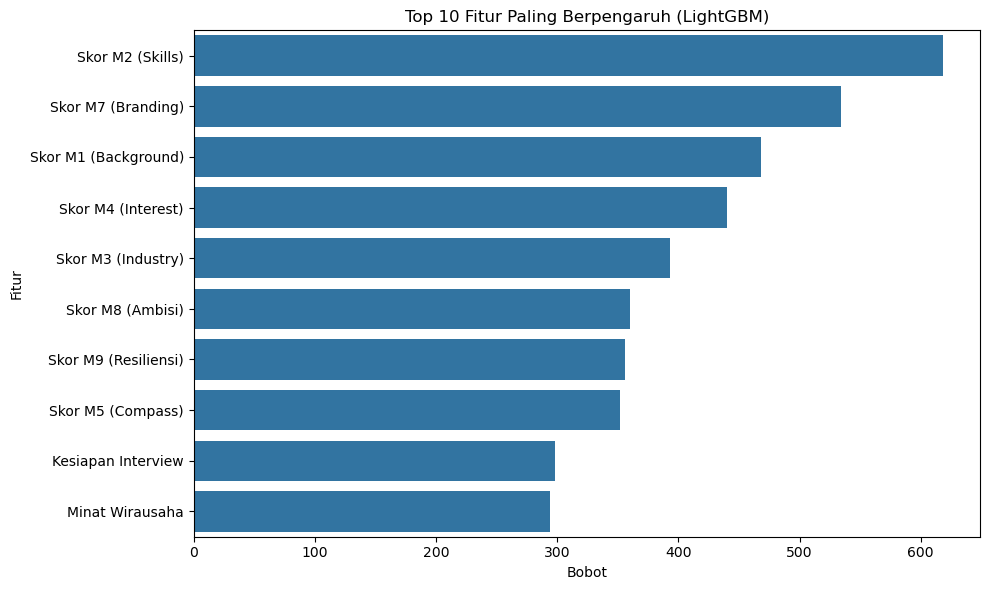

In [12]:
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
import seaborn as sns

# Latih ulang LightGBM di seluruh data untuk melihat Feature Importance
lgbm_final = LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)
lgbm_final.fit(X_encoded, y_macro_encoded)

# Ambil bobot kepentingannya
importances = lgbm_final.feature_importances_
fitur = X_encoded.columns

df_importance = pd.DataFrame({'Fitur': fitur, 'Bobot': importances})
df_importance = df_importance.sort_values(by='Bobot', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Bobot', y='Fitur', data=df_importance)
plt.title('Top 10 Fitur Paling Berpengaruh (LightGBM)')
plt.tight_layout()
plt.show()

Menggunakan **Recursive Feature Elimination with Cross-Validation (RFECV)** untuk mengeliminasi fitur-fitur yang tidak berpengaruh.

=== ELIMINASI FITUR (RFECV) ===
Melakukan eliminasi pada fitur-fitur tertentu.

ELIMINASI SELESAI!
Jumlah Fitur Asli         : 50
Jumlah Fitur Optimal      : 49
Total Fitur yang Dibuang  : 1


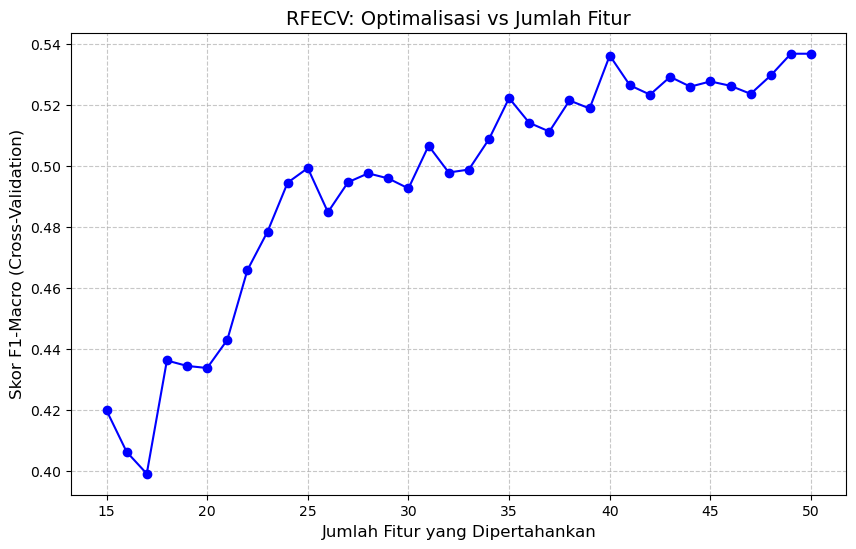

In [13]:
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt

print("=== ELIMINASI FITUR (RFECV) ===")

# Inisiasi Model
model_optimal = LGBMClassifier(
    objective='multiclass',
    class_weight='balanced',
    random_state=42,
    verbosity=-1,
    learning_rate=0.03099899673129621,
    num_leaves=24,
    max_depth=9,
    min_child_samples=32,
    feature_fraction=0.5184349672587325,
    subsample=0.794445472290298
)


# Inisiasi Pemangkas menggunakan model_optimal yang sudah berisi parameter Optuna
rfecv = RFECV(
    estimator=model_optimal,
    step=1,
    cv=skf, 
    scoring='f1_macro',
    min_features_to_select=15, 
    n_jobs=-1
)

# Eksekusi Eliminasi Fitur
print("Melakukan eliminasi pada fitur-fitur tertentu.")
rfecv.fit(X_encoded, y_macro_encoded)

# Laporan Forensik
print("\nELIMINASI SELESAI!")
print(f"Jumlah Fitur Asli         : {X_encoded.shape[1]}")
print(f"Jumlah Fitur Optimal      : {rfecv.n_features_}")
print(f"Total Fitur yang Dibuang  : {X_encoded.shape[1] - rfecv.n_features_}")

# 4. Ekstrak Dataset untuk melatih model final
X_optimized = X_encoded.loc[:, rfecv.support_]
fitur_terpilih = X_optimized.columns.tolist()

# 5. Visualisasi Kurva Fitur
plt.figure(figsize=(10, 6))
plt.title('RFECV: Optimalisasi vs Jumlah Fitur', fontsize=14)
plt.xlabel('Jumlah Fitur yang Dipertahankan', fontsize=12)
plt.ylabel('Skor F1-Macro (Cross-Validation)', fontsize=12)
plt.plot(range(15, len(rfecv.cv_results_['mean_test_score']) + 15), rfecv.cv_results_['mean_test_score'], marker='o', color='b')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Melihat dan Mengecek Fitur-Fitur yang masih dipertahankan.

In [14]:
# ==========================
# Melakukan Pengecekkan terhadap fitur yang masih dipertahankan
# ==========================

# Ekstrak nama seluruh kolom asli dari Tahap 1
semua_fitur = X_encoded.columns

# Deteksi fitur yang dibuang 
fitur_sampah = semua_fitur[~rfecv.support_]

# Deteksi fitur yang dipertahankan
fitur_optimal = semua_fitur[rfecv.support_]

print("DAFTAR FITUR YANG DIHILANGKAN:")
for i, fitur in enumerate(fitur_sampah, 1):
    print(f"{i}. {fitur}")

print("\n" + "="*40 + "\n")

print("DAFTAR FITUR YANG DIPERTAHANKAN:")
print(list(fitur_optimal))

DAFTAR FITUR YANG DIHILANGKAN:
1. Program Studi_Seni_Kreatif


DAFTAR FITUR YANG DIPERTAHANKAN:
['Semester', 'IPK', 'Tempat Magang', 'Skor M1 (Background)', 'Skor M2 (Skills)', 'Skor M3 (Industry)', 'Skor M4 (Interest)', 'Skor M5 (Compass)', 'Skor M6 (Company)', 'Skor M7 (Branding)', 'Skor M8 (Ambisi)', 'Skor M9 (Resiliensi)', 'Ekspektasi Gaji', 'Minat Wirausaha', 'Rencana S2/Sertifikasi', 'Frekuensi Belajar', 'Kesiapan Interview', 'Level Bahasa Inggris', 'Ikut Program VINIX7?_ya', 'Program Studi_Lainnya', 'Program Studi_STEM_Tech', 'Program Studi_Soshum', 'Dream Job_Business Management', 'Dream Job_Creative Marketing', 'Dream Job_Finance Banking', 'Dream Job_Industri Lainnya', 'Dream Job_Tech Data Engineering', 'Jalur Karir_stay', 'Jalur Karir_switch', 'Jalur Karir_unsure', 'Work Style_flex', 'Work Style_small', 'Work Style_solo', 'Cognitive Style_creative', 'Cognitive Style_social', 'Cognitive Style_strategic', 'Motivasi_growth', 'Motivasi_impact', 'Motivasi_money', 'Motivasi_prestig

**TAHAP 5: DEPLOYMENT PREPARATION**

In [15]:
# OPTIMALISASI TERAKHIR dan MELAKUKAN EXPORE FINAL
# ========================

print("=== OPTIMALISASI DAN EKSPOR FINAL ===")

# Latih Ulang 
print("Melatih ulang model dengan seluruh data")
model_optimal.fit(X_optimized, y_macro_encoded)

# Ekspor Ulang 
import joblib

# EKSPOR MODEL
joblib.dump(model_optimal, 'model_lightgbm_vinix.pkl')
joblib.dump(le_macro, 'label_encoder_vinix.pkl')
joblib.dump(list(X_optimized.columns), 'fitur_model_vinix.pkl')

print("EKSPOR BERHASIL")

=== OPTIMALISASI DAN EKSPOR FINAL ===
Melatih ulang model dengan seluruh data
EKSPOR BERHASIL


=== MODEL REPORT ===
Balanced Accuracy : 53.89%

=== CLASSIFICATION REPORT (PER KELAS) ===
                                   precision    recall  f1-score   support

          Bidang Tech dan Digital       0.66      0.62      0.64       592
Industri Konvensional Terstruktur       0.50      0.47      0.48       431
      Industri Kreatif dan Proyek       0.45      0.52      0.48       369

                         accuracy                           0.55      1392
                        macro avg       0.54      0.54      0.54      1392
                     weighted avg       0.56      0.55      0.55      1392



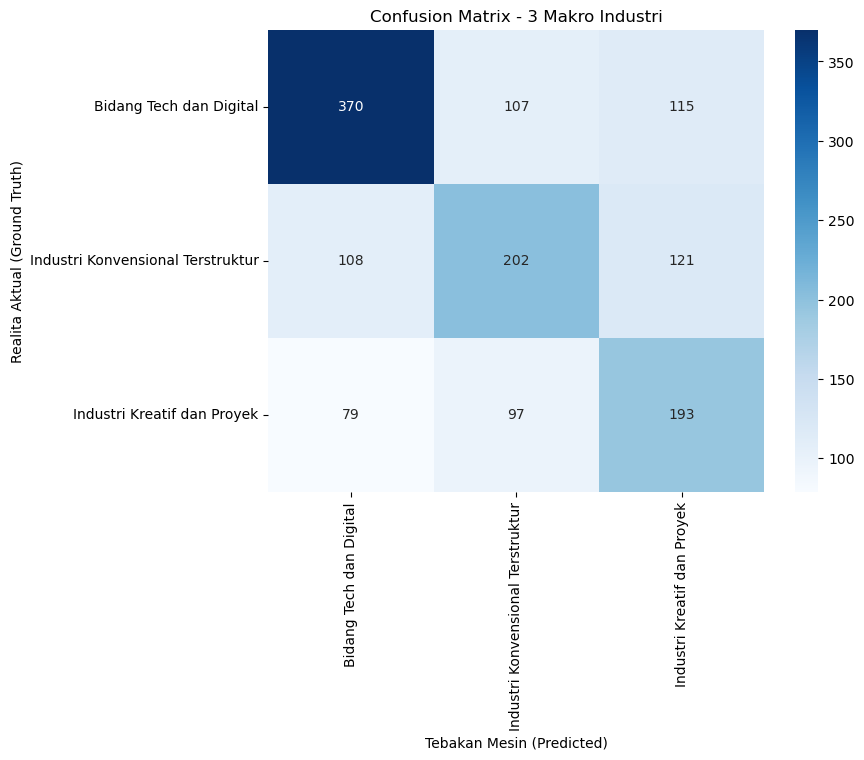

In [16]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

print("=== MODEL REPORT ===")

# Untuk memberikan hasil terbaik model
y_pred_cv = cross_val_predict(model_optimal, X_optimized, y_macro_encoded, cv=skf, n_jobs=-1)

# 2. Balanced Accuracy
b_acc = balanced_accuracy_score(y_macro_encoded, y_pred_cv)
print(f"Balanced Accuracy : {b_acc * 100:.2f}%\n")

# 3. Laporan Performa Per Label 
print("=== CLASSIFICATION REPORT (PER KELAS) ===")
print(classification_report(y_macro_encoded, y_pred_cv, target_names=le_macro.classes_))

# 4. Visualisasi Confusion Matrix
cm = confusion_matrix(y_macro_encoded, y_pred_cv)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_macro.classes_, 
            yticklabels=le_macro.classes_)
plt.ylabel('Realita Aktual (Ground Truth)')
plt.xlabel('Tebakan Mesin (Predicted)')
plt.title('Confusion Matrix - 3 Makro Industri')
plt.show()